<a href="https://colab.research.google.com/github/FaridRash/-thermal-uav-object-detection/blob/main/Farid_1st.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Fetching

In [1]:
!git clone https://github.com/FaridRash/-thermal-uav-object-detection

Cloning into '-thermal-uav-object-detection'...
remote: Enumerating objects: 5751, done.
remote: Total 5751 (delta 0), reused 0 (delta 0), pack-reused 5751 (from 3)
Receiving objects: 100% (5751/5751), 189.72 MiB | 12.62 MiB/s, done.
Updating files: 100% (5734/5734), done.


#Libraries

In [5]:
import matplotlib.pyplot as plt
import os
import pandas as pd


#Annotation Testing


🔹 Showing samples from: train


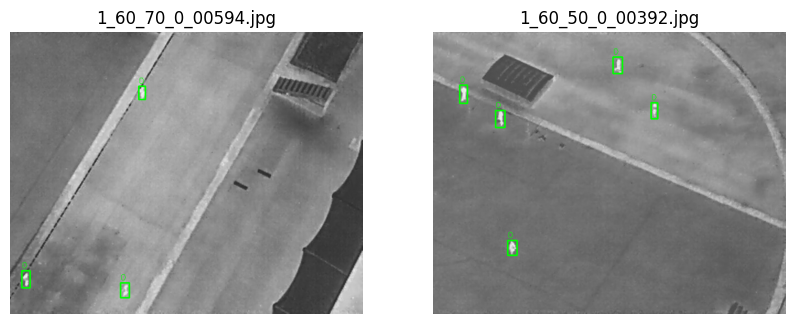


🔹 Showing samples from: val


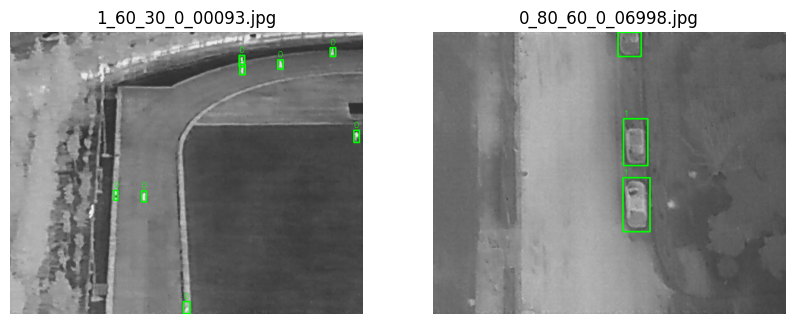


🔹 Showing samples from: test


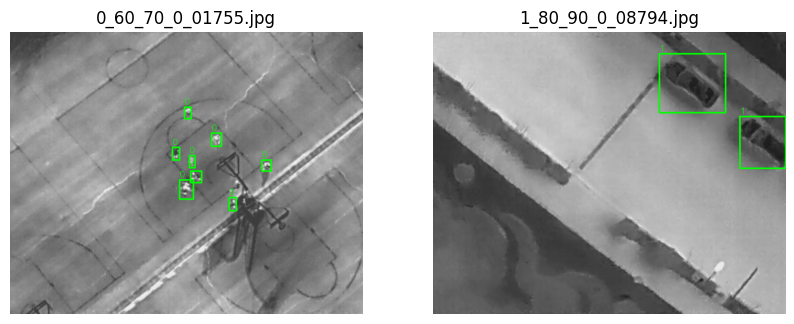

In [8]:
import random
import cv2

# Base paths
images_path = "/content/-thermal-uav-object-detection/Dataset/hit-uav/images"
labels_path = "/content/-thermal-uav-object-detection/Dataset/hit-uav/labels"

splits = ["train", "val", "test"]

def draw_yolo_boxes(image, label_file):
    h, w, _ = image.shape

    if not os.path.exists(label_file):
        return image

    with open(label_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, x, y, bw, bh = map(float, line.strip().split())

        # Convert YOLO → pixel coordinates
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        # Draw box
        cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)

        # Put class id
        cv2.putText(image, f"{int(cls)}", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    return image


for split in splits:
    print(f"\n🔹 Showing samples from: {split}")

    img_dir = os.path.join(images_path, split)
    lbl_dir = os.path.join(labels_path, split)

    images = os.listdir(img_dir)
    selected = random.sample(images, 2)

    plt.figure(figsize=(10,5))

    for i, img_name in enumerate(selected):
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(lbl_dir, img_name.replace(".jpg", ".txt"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = draw_yolo_boxes(image, label_path)

        plt.subplot(1, 2, i+1)
        plt.imshow(image)
        plt.title(img_name)
        plt.axis("off")

    plt.show()

#Collect the Annotation Info

In [9]:
base_path = "/content/-thermal-uav-object-detection/Dataset/hit-uav/labels"

data = []

subfolders = ["train", "test", "val"]

for sub in subfolders:
    folder_path = os.path.join(base_path, sub)

    for file in os.listdir(folder_path):
        if file.endswith(".txt"):
            file_path = os.path.join(folder_path, file)
            image_id = file.replace(".txt", "")

            with open(file_path, "r") as f:
                lines = f.readlines()

                for line in lines:
                    parts = line.strip().split()

                    # Safety check (important for corrupted labels)
                    if len(parts) != 5:
                        continue

                    class_id = int(parts[0])
                    width = float(parts[3])
                    height = float(parts[4])

                    data.append([
                        sub,           # train/test/val
                        image_id,
                        class_id,
                        width,
                        height
                    ])

df = pd.DataFrame(data, columns=[
    "subset",
    "image_id",
    "object_id",
    "width",
    "height"
])

df.head()

,subset,image_id,object_id,width,height
0,train,1_120_30_0_09289,1,0.034375,0.056641
1,train,1_120_30_0_09289,0,0.009375,0.029297
2,train,1_120_30_0_09289,0,0.010937,0.031250
3,train,1_120_30_0_09289,0,0.010937,0.031250
4,train,0_110_40_0_08369,1,0.029687,0.072266
